In [ ]:
#@title Let's check if we are using the GPU. If not, go to **Runtime** $\rightarrow$ **Change runtime type** $\rightarrow$ **T4 GPU**
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('nvidia-smi')

In [ ]:
#@title Install required libraries
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('pip install -qq -U diffusers==0.32.2 transformers==4.49.0 accelerate==1.5.1 scipy==1.15.2 safetensors==0.5.3 invisible_watermark>=0.2.0')

In [ ]:
#@title Download the model
import PIL
import requests
import torch
from io import BytesIO
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

def download_image(url):
    response = requests.get(url)
    return PIL.Image.open(BytesIO(response.content)).convert("RGB")

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device == "cuda" else torch.float32

repo_id = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"
pipe = DiffusionPipeline.from_pretrained(
    repo_id,
    torch_dtype=dtype,
    use_safetensors=True,
    variant="fp16" if device == "cuda" else None,
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

model_index.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /Users/fbi005/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Users/fbi005/.cache/huggingface/hub/models--diffusers--stable-diffusion-xl-1.0-inpainting-0.1/snapshots/115134f363124c53c7d878647567d04daf26e41e/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

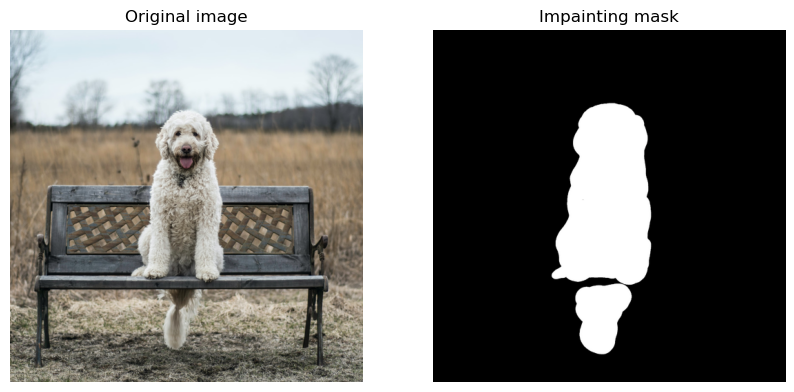

In [ ]:
#@title Provide image and mask
import matplotlib.pyplot as plt
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png" #@param {type:'string'}
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png" #@param {type:'string'}

init_image = download_image(img_url).resize((512, 512))
mask_image = download_image(mask_url).resize((512, 512))

f, axs = plt.subplots(1, 2, figsize=(10, 20))
axs[0].imshow(init_image)
axs[0].set_title("Original image")
axs[0].axis('off')
axs[1].imshow(mask_image)
axs[1].set_title("Impainting mask")
axs[1].axis('off')

  0%|          | 0/29 [00:00<?, ?it/s]

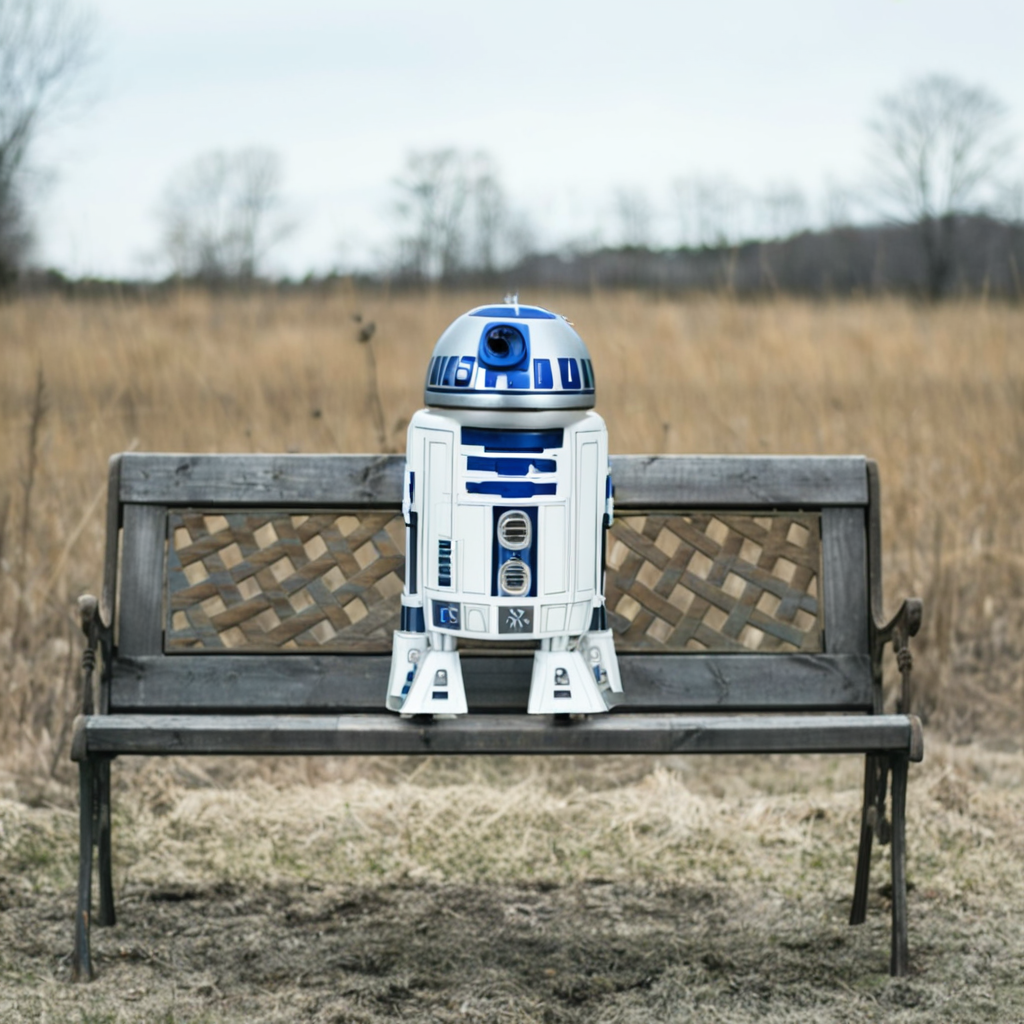

In [ ]:
#@title Impaint
prompt = "r2d2 sitting on a bench" #@param {type:'string'}
image = pipe(prompt=prompt, image=init_image, mask_image=mask_image, num_inference_steps=30).images[0]
image